In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx # we will use it for visualization
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.optimize import milp
from scipy import optimize
from scipy.sparse.csgraph import shortest_path

## Stationary Enviroment

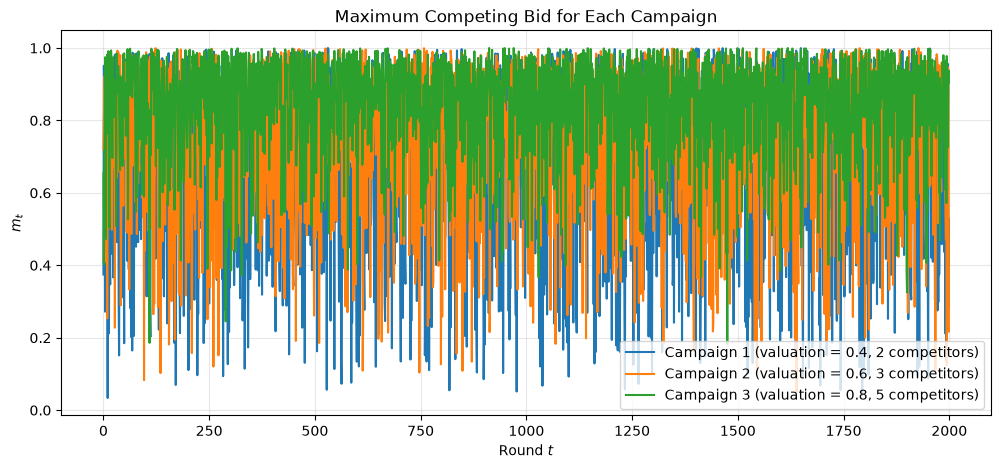

Campaign valuations: [0.4 0.6 0.8]
Number of competitors: [2, 3, 5]
Shape of m_t: (3, 2000)
Budget per round: 0.15


In [2]:
# Reproducibility
np.random.seed(42)

# Problem parameters
n_campaigns = 3
n_users = 2000  # Number of rounds
B = 300
rho = B / n_users

# Different valuation for each campaign
my_valuations = np.array([0.4, 0.6, 0.8])

# Different number of competitors for each campaign
n_competitors = [2, 3, 5]

# Generate uniformly distributed bids for each campaign
other_bids = [
    np.random.uniform(
        0,
        1,
        size=(n_competitors[campaign], n_users)
    )
    for campaign in range(n_campaigns)
]

# Maximum competing bid for each campaign and round
m_t = np.array([
    campaign_bids.max(axis=0)
    for campaign_bids in other_bids
])

# Plot the maximum competing bid for each campaign
plt.figure(figsize=(12, 5))

for campaign in range(n_campaigns):
    plt.plot(
        m_t[campaign],
        label=(
            f"Campaign {campaign + 1} "
            f"(valuation = {my_valuations[campaign]}, "
            f"{n_competitors[campaign]} competitors)"
        )
    )

plt.title("Maximum Competing Bid for Each Campaign")
plt.xlabel("Round $t$")
plt.ylabel("$m_t$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Campaign valuations:", my_valuations)
print("Number of competitors:", n_competitors)
print("Shape of m_t:", m_t.shape)
print("Budget per round:", rho)